# SmartCare Option C - Task 07: Explainable AI Analysis

This notebook explains the saved Logistic Regression pipeline using SHAP. It covers global importance, class-specific behaviour, individual predictions, the single incorrect test prediction, transparency, and ethical implications.

> SHAP explains how the model uses the supplied synthetic variables. It does not prove medical causation or clinical validity.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
CLASS_NAMES = ["Low", "Medium", "High"]
CLASS_TO_INT = {name: index for index, name in enumerate(CLASS_NAMES)}
INT_TO_CLASS = {index: name for name, index in CLASS_TO_INT.items()}

D:\AI Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the saved model and reconstruct the verified test set

In [2]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "smartcare_ai_dataset_1000.csv"
MODEL_PATH = PROJECT_DIR / "models" / "smartcare_option_c_best_pipeline.joblib"
METADATA_PATH = PROJECT_DIR / "models" / "smartcare_option_c_metadata.json"
FIGURE_DIR = PROJECT_DIR / "reports" / "figures"
TABLE_DIR = PROJECT_DIR / "reports" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
best_pipeline = joblib.load(MODEL_PATH)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]
df["mean_arterial_pressure"] = (df["systolic_bp"] + 2 * df["diastolic_bp"]) / 3
df["has_previous_admission"] = (df["previous_admissions"] > 0).astype(int)

features = metadata["features"]
y = df[metadata["target"]].map(CLASS_TO_INT).astype(int)
train_index, test_index = train_test_split(
    np.arange(len(df)), test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train = df.iloc[train_index][features].reset_index(drop=True)
X_test = df.iloc[test_index][features].reset_index(drop=True)
y_train = y.iloc[train_index].reset_index(drop=True)
y_test = y.iloc[test_index].reset_index(drop=True)
predictions = best_pipeline.predict(X_test)
probabilities = best_pipeline.predict_proba(X_test)

print(f"Model: {metadata['algorithm']} | Feature set: {metadata['feature_set']}")
print(f"Training records: {len(X_train)} | Test records: {len(X_test)}")
print(f"Correct predictions: {(predictions == y_test.to_numpy()).sum()}/{len(y_test)}")
assert np.isclose((predictions == y_test.to_numpy()).mean(), metadata["test_metrics"]["Accuracy"]), "Reconstructed test result differs from saved metadata."

Model: Logistic Regression | Feature set: Clinical only
Training records: 800 | Test records: 200
Correct predictions: 199/200


## 2. Calculate SHAP values

For multiclass Logistic Regression, SHAP explains each class score (logit). Positive SHAP values push the model toward that class; negative values push it away. The final probabilities are produced by applying softmax across the three class scores.

In [3]:
preprocessor = best_pipeline.named_steps["preprocessor"]
classifier = best_pipeline.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
raw_feature_names = preprocessor.get_feature_names_out()
transformed_feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in raw_feature_names
]

masker = shap.maskers.Independent(X_train_transformed, max_samples=len(X_train_transformed))
explainer = shap.LinearExplainer(classifier, masker)
shap_values = explainer(X_test_transformed)

print(f"Transformed test matrix: {X_test_transformed.shape}")
print(f"SHAP values: {shap_values.values.shape} = patients x transformed features x classes")
print("Transformed features:")
print(transformed_feature_names)

Transformed test matrix: (200, 12)
SHAP values: (200, 12, 3) = patients x transformed features x classes
Transformed features:
['age', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'pulse_pressure', 'mean_arterial_pressure', 'has_previous_admission', 'gender_Female', 'gender_Male']


## 3. Global SHAP importance across all three classes

,feature,mean_absolute_shap
4,blood_sugar_mg_dl,8.2572
5,cholesterol_mg_dl,7.3560
6,bmi,7.3239
0,age,6.6976
1,previous_admissions,4.8973
10,gender_Female,2.2835
11,gender_Male,2.2110
2,systolic_bp,1.8590
7,pulse_pressure,1.5916
8,mean_arterial_pressure,1.1337


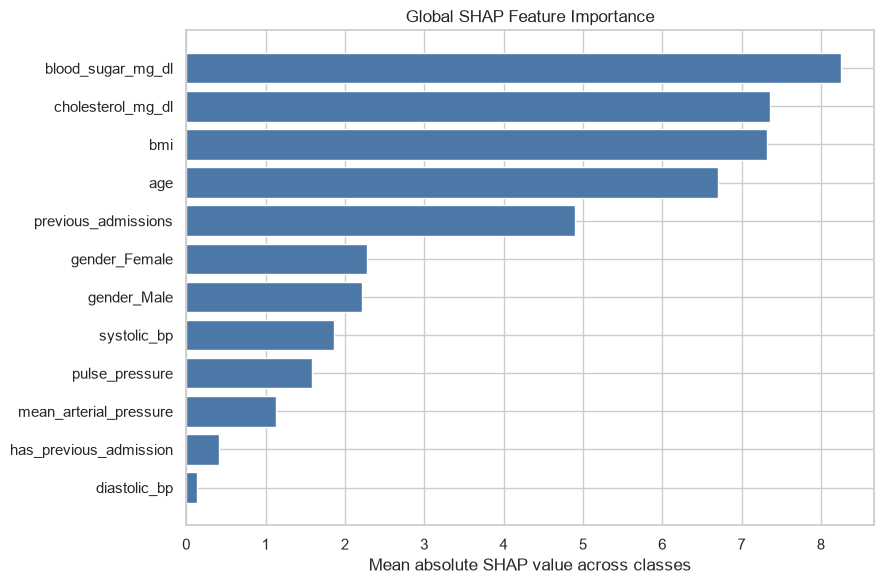

In [4]:
global_importance = np.abs(shap_values.values).mean(axis=(0, 2))
global_importance_table = pd.DataFrame({
    "feature": transformed_feature_names,
    "mean_absolute_shap": global_importance,
}).sort_values("mean_absolute_shap", ascending=False)
global_importance_table.to_csv(TABLE_DIR / "xai_global_shap_importance.csv", index=False)
display(global_importance_table.round(4))

plot_data = global_importance_table.sort_values("mean_absolute_shap")
plt.figure(figsize=(9, 6))
plt.barh(plot_data["feature"], plot_data["mean_absolute_shap"], color="#4c78a8")
plt.xlabel("Mean absolute SHAP value across classes")
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "xai_global_shap_importance.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Class-specific importance and direction

A feature may push differently toward Low, Medium, or High risk. These plots must therefore be interpreted separately for each class.

,Low,Medium,High,Overall
blood_sugar_mg_dl,12.1399,0.2459,12.3857,8.2572
cholesterol_mg_dl,10.7407,0.2933,11.0340,7.3560
bmi,10.4983,0.4875,10.9858,7.3239
age,9.6144,0.4320,10.0464,6.6976
previous_admissions,6.4858,0.8602,7.3460,4.8973
gender_Female,3.4252,2.3171,1.1081,2.2835
gender_Male,3.3165,2.4207,0.8958,2.2110
systolic_bp,2.6078,0.1807,2.7885,1.8590
pulse_pressure,2.1772,0.2102,2.3874,1.5916
mean_arterial_pressure,1.6627,0.0379,1.7006,1.1337


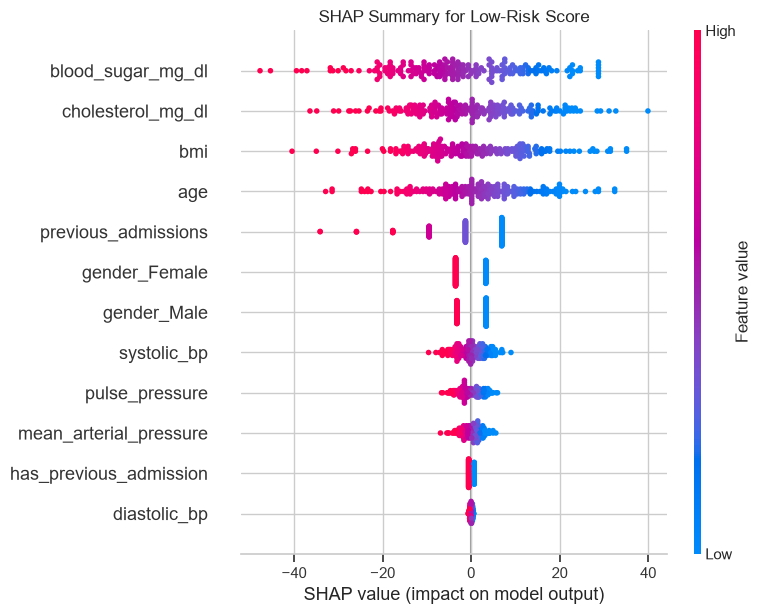

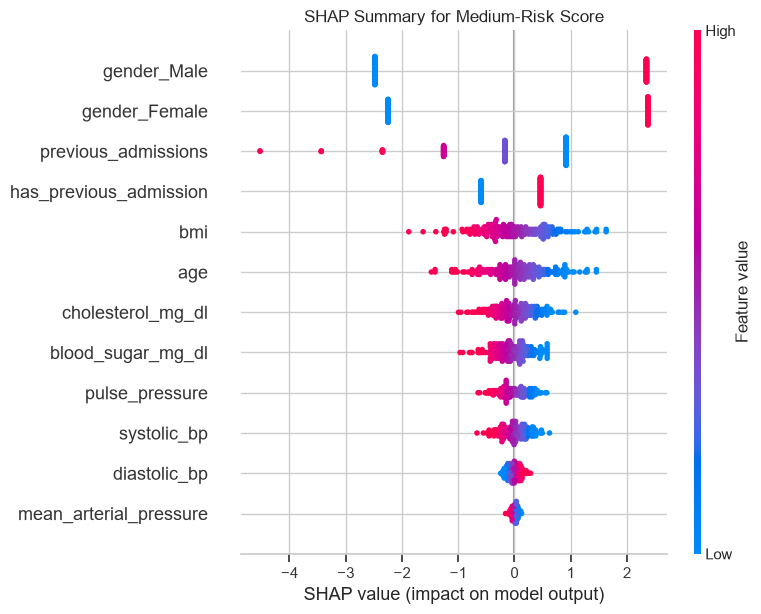

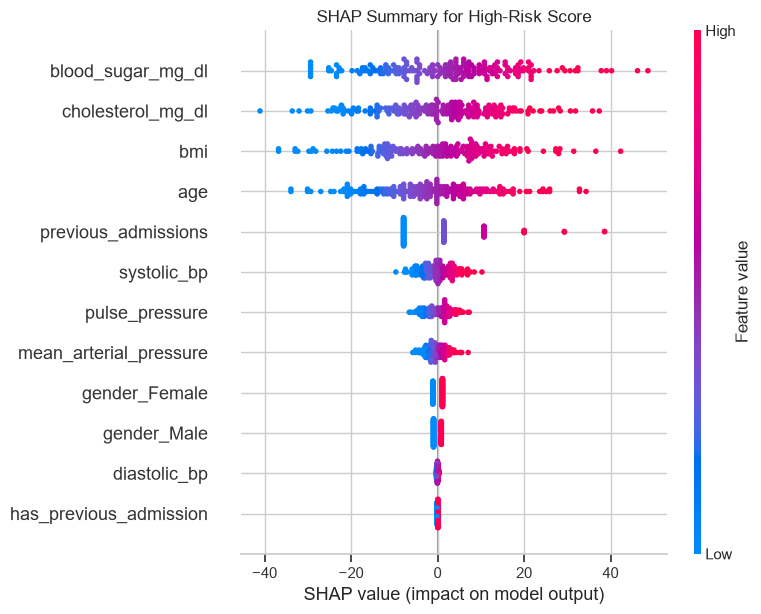

In [5]:
class_importance = pd.DataFrame({
    class_name: np.abs(shap_values.values[:, :, class_index]).mean(axis=0)
    for class_index, class_name in enumerate(CLASS_NAMES)
}, index=transformed_feature_names)
class_importance["Overall"] = class_importance.mean(axis=1)
class_importance = class_importance.sort_values("Overall", ascending=False)
class_importance.to_csv(TABLE_DIR / "xai_class_specific_shap_importance.csv")
display(class_importance.round(4))

for class_index, class_name in enumerate(CLASS_NAMES):
    shap.summary_plot(
        shap_values.values[:, :, class_index],
        X_test_transformed,
        feature_names=transformed_feature_names,
        max_display=12,
        show=False,
    )
    plt.title(f"SHAP Summary for {class_name}-Risk Score")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"xai_shap_summary_{class_name.lower()}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. Direction check using Logistic Regression coefficients

Positive coefficients increase a class score; negative coefficients reduce it. Coefficients and SHAP should tell a consistent story because this is a linear model.

In [6]:
coefficient_table = pd.DataFrame(
    classifier.coef_.T,
    index=transformed_feature_names,
    columns=[f"coefficient_{name.lower()}" for name in CLASS_NAMES],
)
coefficient_table["largest_absolute_coefficient"] = coefficient_table.abs().max(axis=1)
coefficient_table = coefficient_table.sort_values("largest_absolute_coefficient", ascending=False)
coefficient_table.to_csv(TABLE_DIR / "xai_logistic_coefficients.csv")
display(coefficient_table.round(4))

,coefficient_low,coefficient_medium,coefficient_high,largest_absolute_coefficient
blood_sugar_mg_dl,-15.3203,-0.3103,15.6306,15.6306
cholesterol_mg_dl,-14.0828,-0.3845,14.4673,14.4673
age,-13.2580,-0.5958,13.8537,13.8537
bmi,-12.8663,-0.5975,13.4638,13.4638
previous_admissions,-7.7174,-1.0235,8.7409,8.7409
gender_Female,-6.8316,4.6214,2.2102,6.8316
gender_Male,-6.6148,4.8281,1.7867,6.6148
systolic_bp,-3.1859,-0.2208,3.4067,3.4067
pulse_pressure,-2.5849,-0.2495,2.8344,2.8344
mean_arterial_pressure,-2.0885,-0.0476,2.1361,2.1361


## 6. Local explanations for individual patients

The following cases include one confidently correct example from each class and the only incorrect test prediction. Waterfall plots begin at the average class score and show how each feature moves the patient toward or away from the selected class.

In [7]:
correct_mask = predictions == y_test.to_numpy()
selected_cases = {}
for class_index, class_name in enumerate(CLASS_NAMES):
    candidates = np.where(correct_mask & (y_test.to_numpy() == class_index))[0]
    selected_cases[f"Correct {class_name}"] = int(candidates[np.argmax(probabilities[candidates, class_index])])

incorrect_indices = np.where(~correct_mask)[0]
if len(incorrect_indices):
    selected_cases["Incorrect case"] = int(incorrect_indices[0])

case_rows = []
for label, row_index in selected_cases.items():
    row = {
        "case": label,
        "test_row": row_index,
        "actual": INT_TO_CLASS[int(y_test.iloc[row_index])],
        "predicted": INT_TO_CLASS[int(predictions[row_index])],
        "confidence": probabilities[row_index].max(),
        "probability_low": probabilities[row_index, 0],
        "probability_medium": probabilities[row_index, 1],
        "probability_high": probabilities[row_index, 2],
    }
    case_rows.append(row)
case_summary = pd.DataFrame(case_rows)
display(case_summary.round(4))

,case,test_row,actual,predicted,confidence,probability_low,probability_medium,probability_high
0,Correct Low,91,Low,Low,1.0000,1.0000,0.0000,0.0
1,Correct Medium,11,Medium,Medium,1.0000,0.0000,1.0000,0.0
2,Correct High,4,High,High,1.0000,0.0000,0.0000,1.0
3,Incorrect case,134,Medium,Low,0.8513,0.8513,0.1487,0.0


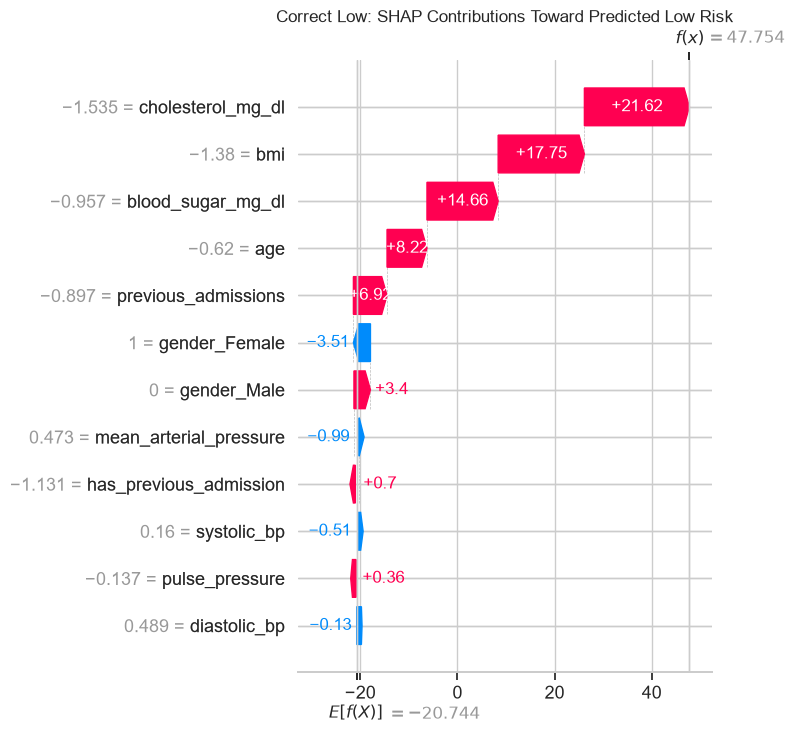

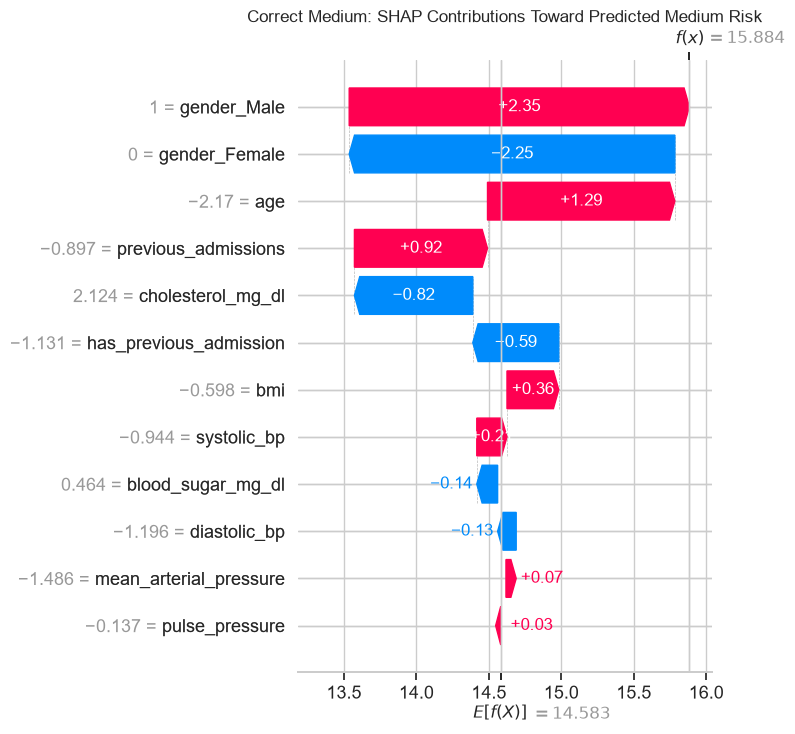

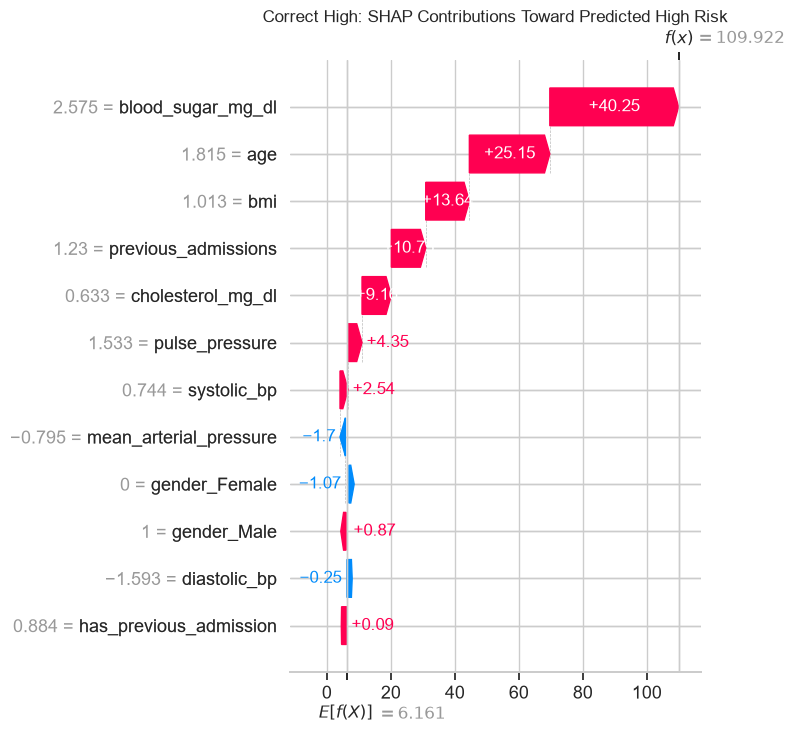

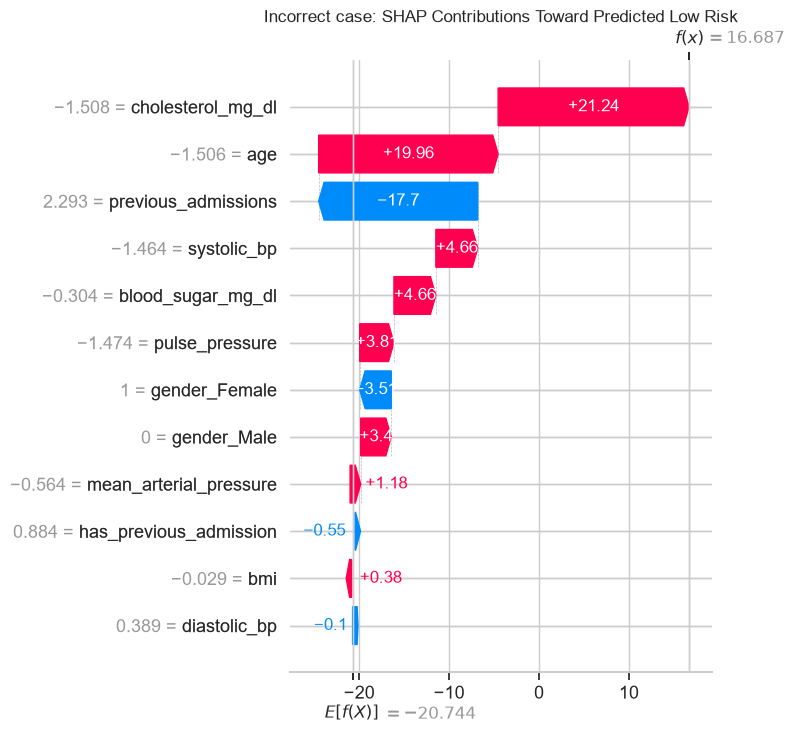

In [8]:
def plot_case_waterfall(row_index, explained_class, title, filename):
    explanation = shap.Explanation(
        values=shap_values.values[row_index, :, explained_class],
        base_values=shap_values.base_values[row_index, explained_class],
        data=X_test_transformed[row_index],
        feature_names=transformed_feature_names,
    )
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

for label, row_index in selected_cases.items():
    predicted_class = int(predictions[row_index])
    plot_case_waterfall(
        row_index, predicted_class,
        f"{label}: SHAP Contributions Toward Predicted {INT_TO_CLASS[predicted_class]} Risk",
        f"xai_waterfall_{label.lower().replace(' ', '_')}_predicted.png",
    )


## 7. Explain the incorrect Medium-to-Low prediction

,patient_value
age,18
previous_admissions,3
systolic_bp,106
diastolic_bp,83
blood_sugar_mg_dl,106
cholesterol_mg_dl,149
bmi,25.4
pulse_pressure,23
mean_arterial_pressure,90.666667
has_previous_admission,1


Actual: Medium | Predicted: Low | Confidence: 0.851


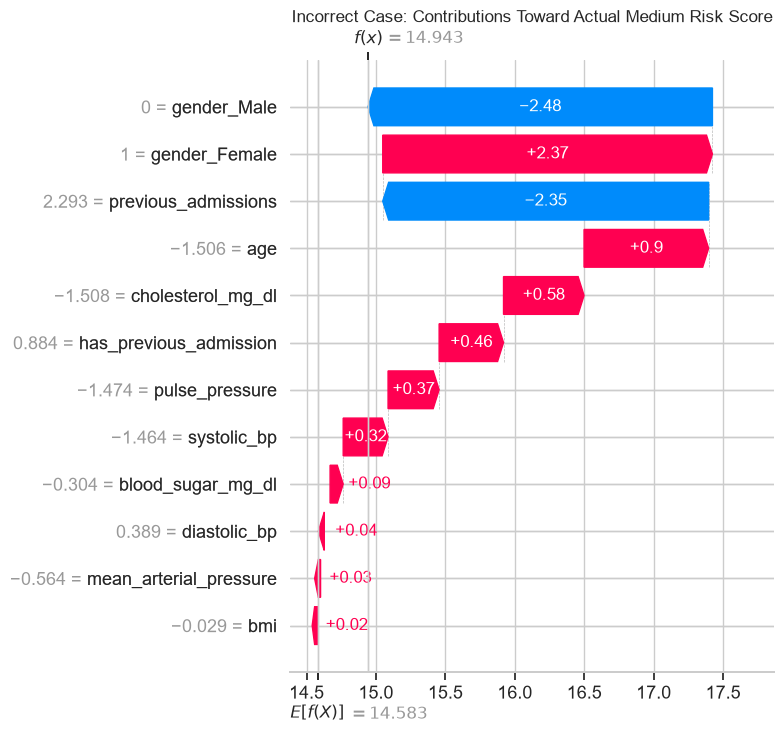

In [9]:
if len(incorrect_indices):
    error_index = int(incorrect_indices[0])
    actual_class = int(y_test.iloc[error_index])
    predicted_class = int(predictions[error_index])
    patient_values = X_test.iloc[error_index].to_frame("patient_value")
    display(patient_values)
    print(
        f"Actual: {INT_TO_CLASS[actual_class]} | Predicted: {INT_TO_CLASS[predicted_class]} | "
        f"Confidence: {probabilities[error_index, predicted_class]:.3f}"
    )
    plot_case_waterfall(
        error_index, actual_class,
        f"Incorrect Case: Contributions Toward Actual {INT_TO_CLASS[actual_class]} Risk Score",
        "xai_incorrect_case_actual_class.png",
    )
else:
    print("No incorrect test prediction was available for error analysis.")

## 8. Interpretation for the technical report

The SHAP analysis identifies the variables on which the final model relies most strongly and separates their influence by risk class. For an individual patient, positive contributions increase a selected class score while negative contributions reduce it. Because the risk labels are ordered, borderline patients can contain competing evidence for neighbouring classes. The incorrect case should therefore be discussed as a boundary error rather than evidence that a particular measurement medically caused the prediction.

The agreement between SHAP, permutation importance and the Logistic Regression coefficients increases confidence that the fitted model is behaving consistently. Nevertheless, consistency is not clinical validation. The unusually high performance and strong separation produced by a simple linear model suggest that the synthetic target was probably constructed from a relatively simple combination of the clinical measurements.

## 9. Transparency and ethical implications

- **Decision support only:** The model must not replace a clinician or provide autonomous diagnosis.
- **Synthetic data limitation:** Results show reproduction of supplied synthetic labels, not demonstrated clinical effectiveness.
- **Unknown labelling protocol:** The dataset does not document how `disease_risk_level` was clinically established.
- **Explanation is not causation:** SHAP values describe model behaviour and must not be presented as proof that a variable causes disease.
- **Risk of automation bias:** Users may trust a confident output even when it is wrong, as demonstrated by the Medium-to-Low case.
- **Subgroup fairness:** Performance should be checked across gender and age groups before any wider use. Synthetic subgroup results cannot establish real-world fairness.
- **Privacy:** A real deployment would require secure handling of identifiable clinical data, access control and audit logging.
- **Human oversight:** Uncertain or conflicting predictions should be referred for professional review.

### Task 07 conclusion

The final Logistic Regression pipeline is transparent at both global and patient levels. SHAP exposes the features that drive each class score and helps audit correct and incorrect predictions. The analysis satisfies the coursework requirement for important features, prediction reasoning, transparency and ethical implications, while clearly limiting claims to an educational prototype trained on synthetic data.